In [1]:
import time, os, sys, pickle, h5py, importlib, gc, copy, re, itertools, json, logging
from tqdm.auto import tqdm, trange
from pathlib import Path
from util import config_logger

import numpy as np, pandas as pd, scipy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

from umap import UMAP

import torch
torch.set_num_threads(16)

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("white")
%matplotlib inline
%config InlineBackend.figure_format='retina'


logger = config_logger(logging.getLogger(__name__))
import scanpy as sc
from scipy.spatial import Delaunay
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


In [17]:
s = '/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/ST/unbinned_ST/ST.h5ad /data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/ST/ST_55_python.h5ad cell_type /data/narein/ST_deconvolution_Tanush/Data/MERFISH_Ileum/final_outputs'

In [18]:
s.split(' ')

['/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/ST/unbinned_ST/ST.h5ad',
 '/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/ST/ST_55_python.h5ad',
 'cell_type',
 '/data/narein/ST_deconvolution_Tanush/Data/MERFISH_Ileum/final_outputs']

In [2]:

st_path = s.split(' ')[1]
sc_path = s.split(' ')[0]
path = s.split(' ')[3]
output_path = path + "output_SpiceMix.csv"
celltype_key = s.split(' ')[2]
folder_path = "/data/narein/ST_deconvolution_Tanush/Data/Cerebellum/junk/files/"
os.makedirs(Path(folder_path), exist_ok=True)
os.makedirs(Path(path + "SpiceMix/"), exist_ok=True)

In [3]:
import anndata
st_data = anndata.read_h5ad(Path(st_path))
st_data.X = scipy.sparse.csr_matrix(st_data.X)
st_data

AnnData object with n_obs × n_vars = 33932 × 500
    obs: 'Cancer_subtype1', 'Cancer_subtype2', 'TAM_SPP1', 'TAM_C1Q', 'Fibroblasts1', 'T/NK_Cells', 'Endothelial_cells', 'Dendritic_cells', 'B_cells', 'dataset', 'umi_count'
    obsm: 'spatial'

In [4]:
sc.pp.filter_cells(st_data, min_genes= 1)
sc.pp.filter_genes(st_data, min_cells = 1)
sc.pp.normalize_total(st_data, target_sum=1e4)
sc.pp.log1p(st_data)
st_data


AnnData object with n_obs × n_vars = 33932 × 500
    obs: 'Cancer_subtype1', 'Cancer_subtype2', 'TAM_SPP1', 'TAM_C1Q', 'Fibroblasts1', 'T/NK_Cells', 'Endothelial_cells', 'Dendritic_cells', 'B_cells', 'dataset', 'umi_count', 'n_genes'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'spatial'

In [5]:
#df = st_data.obs[['array_row','array_col']]
df = pd.DataFrame(st_data.obsm['spatial'], columns = ['new_x','new_y'], index = st_data.obs.index)
#df = st_data.obs[['new_x','new_y']]
df.rename(columns = {'array_row':'coor X', 'array_col':'coord Y', 'new_x':'coor X', 'new_y':'coord Y'})
df.reset_index(drop = True, inplace = True)
df.to_csv(folder_path + 'meta_0.csv')
np.savetxt(folder_path+"expression_0.txt",st_data.X.todense())

In [6]:
def knn_graph(data, k):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    edges = []
    for i, neighbors in enumerate(indices):
        for neighbor in neighbors[1:]:  # Skip the first element (itself)
            edges.append((i, neighbor))
    df = pd.DataFrame(edges, columns=['edge1', 'edge2'])
    return df
k = 6
knn_df = knn_graph(df, k)
np.savetxt(folder_path + "neighborhood_0.txt",np.array(knn_df), fmt = '%d')
np.savetxt(folder_path + "genes_0.txt",st_data.var_names.to_numpy().reshape(-1,1).astype(str), fmt = '%s')

In [7]:
sc_data = anndata.read_h5ad(sc_path)
K = len(np.unique(sc_data.obs[celltype_key]))

In [8]:
sc_data.var_names_make_unique()
sc.pp.filter_cells(sc_data, min_genes = 1)

In [9]:
context = dict(device='cpu', dtype=torch.float64)
path2dataset = Path(folder_path[:-6])
repli_list = ['0']

In [10]:
from model import SpiceMix

np.random.seed(0)

num_pcs, n_neighbors, res_lo, res_hi = 50, 20, .5, 2.

path2result = path2dataset / 'results' / 'SpiceMix.h5'
os.makedirs(path2result.parent, exist_ok=True)
if os.path.exists(path2result):
    os.remove(path2result)

obj = SpiceMix(
    K=K,
    lambda_Sigma_x_inv=1e-6, power_Sigma_x_inv=2,
    repli_list=repli_list,
    context=context,
    context_Y=context,
    path2result=path2result,
)
obj.load_dataset(path2dataset)
#obj.meta['cell type'] = pd.Categorical(obj.meta['cell type'])
# --
obj.initialize(
    method='louvain', kwargs=dict(num_pcs=num_pcs, n_neighbors=n_neighbors, resolution_boundaries=(res_lo, res_hi), num_rs=10),
)
for iiter in range(10):
    obj.estimate_weights(iiter=iiter, use_spatial=[False]*obj.num_repli)
    obj.estimate_parameters(iiter=iiter, use_spatial=[False]*obj.num_repli)
obj.initialize_Sigma_x_inv()
for iiter in range(1, 201):
    logger.info(f'Iteration {iiter}')
    obj.estimate_parameters(iiter=iiter, use_spatial=[True]*obj.num_repli)
    obj.estimate_weights(iiter=iiter, use_spatial=[True]*obj.num_repli)

2024-10-22 21:03:57:INFO:result file = /data/narein/ST_deconvolution_Tanush/Data/Cerebellum/junk/results/SpiceMix.h5
2024-10-22 21:04:06:INFO:Loaded 33932 cells and 500 genes from /data/narein/ST_deconvolution_Tanush/Data/Cerebellum/junk/files/expression_0.txt
2024-10-22 21:04:06:INFO:Loaded 500 genes from /data/narein/ST_deconvolution_Tanush/Data/Cerebellum/junk/files/genes_0.txt
2024-10-22 21:04:07:WARNING:Detected 94319 duplicate edge(s) from 203592 loaded edges. Duplicate edges are discarded.
2024-10-22 21:04:07:INFO:Loaded 109273 edges from /data/narein/ST_deconvolution_Tanush/Data/Cerebellum/junk/files/neighborhood_0.txt
Louvain clustering: res=1.00e+00; best: score = 0.77 rs = 4 # of clusters = 14: 100%|██████████| 10/10 [01:03<00:00,  6.37s/it]
Louvain clustering: res=7.07e-01; best: score = 0.80 rs = 0 # of clusters = 11: 100%|██████████| 10/10 [01:07<00:00,  6.76s/it]
Louvain clustering: res=5.95e-01; best: score = 0.81 rs = 0 # of clusters = 9: 100%|██████████| 10/10 [01:09<

In [11]:
latent_states = [X.cpu().numpy() for X in obj.Xs]
latent_state_cat = np.concatenate(latent_states, axis=0)
M = pd.DataFrame(obj.M.T.numpy())
M.columns = st_data.var_names.to_numpy()
M.to_csv(path + "SpiceMix/M.csv")
L = pd.DataFrame(latent_state_cat)
L.index = st_data.obs_names.to_numpy()
L.to_csv(path + "SpiceMix/L.csv")

In [12]:
## Code for celltype assignment starts, here
## M is the cell type x gene matrix output by the method, its columns should have gene names
sc_data = sc_data[:,M.columns.to_numpy()]
df = M.copy()
df.index = np.unique(sc_data.obs[celltype_key])
df = df.fillna(0)
for ct in np.unique(sc_data.obs[celltype_key]):
    print(ct)
    sub = sc_data[sc_data.obs[celltype_key]==ct]
    exp = np.array(sub.X.sum(axis=0)).reshape(-1)
    df.loc[ct,:] = exp

B_cells
Cancer_subtype1
Cancer_subtype2
Dendritic_cells
Endothelial_cells
Fibroblasts1
T/NK_Cells
TAM_C1Q
TAM_SPP1


In [13]:
correlations = pd.DataFrame(index = np.unique(sc_data.obs[celltype_key]), columns = M.index)
correlations = correlations.fillna(0)
for i in range(K):
    for j in range(K):
        cor = np.corrcoef(df.iloc[i,:],M.iloc[j])[1][0]
        correlations.iloc[i,j] = cor
correlations.to_csv(path + "SpiceMix/correlations.csv")

In [14]:
assignment = {}
for i in range(K):
    latent = correlations.max().idxmax()
    ct = correlations.loc[:,latent].idxmax()
    assignment[latent] = ct
    correlations.loc[:,latent] = -1
    correlations.loc[ct,:] = -1


In [15]:
output = pd.DataFrame(latent_state_cat)
output.columns = output.columns.map(assignment)
output.index = st_data.obs.index
output = output.div(output.sum(axis=1),axis=0)
output = output[np.sort(output.columns)]
output.to_csv(output_path)

In [93]:
output

,B cell,CD1c-positive myeloid dendritic cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta T cell",alveolar macrophage,bronchus fibroblast of lung,capillary endothelial cell,classical monocyte,club cell,conventional dendritic cell,...,pericyte,plasma cell,plasmacytoid dendritic cell,pulmonary artery endothelial cell,regulatory T cell,smooth muscle cell,stromal cell,type I pneumocyte,type II pneumocyte,vein endothelial cell
s_016um_00052_00082-1,0.000000,0.0,0.001997,0.000000,0.000000,0.000000,0.000000,0.000932,0.020929,0.143284,...,0.036167,0.014747,0.032410,0.041866,0.028632,0.000000,0.007484,0.051121,0.043996,0.142052
s_016um_00163_00399-1,0.036880,0.0,0.000000,0.000000,0.000000,0.111197,0.107304,0.145091,0.000000,0.000000,...,0.192914,0.020992,0.080796,0.000000,0.000000,0.000000,0.051175,0.000000,0.067295,0.000000
s_016um_00238_00388-1,0.000000,0.0,0.020305,0.000000,0.000000,0.000000,0.022316,0.000000,0.017938,0.000000,...,0.000000,0.040873,0.322082,0.000000,0.000000,0.000000,0.024745,0.000000,0.064292,0.000000
s_016um_00144_00175-1,0.085282,0.0,0.000783,0.100221,0.000000,0.093527,0.079163,0.008113,0.016811,0.077113,...,0.010903,0.028099,0.018326,0.214956,0.000000,0.000000,0.003332,0.100371,0.000000,0.024522
s_016um_00297_00147-1,0.027618,0.0,0.001892,0.068752,0.000000,0.084463,0.011082,0.002705,0.010487,0.052405,...,0.009023,0.005103,0.005286,0.129895,0.000000,0.000000,0.023426,0.039575,0.017877,0.005468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_016um_00375_00231-1,0.000000,0.0,0.121577,0.000000,0.000000,0.000000,0.000000,0.000000,0.003413,0.000000,...,0.000000,0.040999,0.000000,0.000000,0.000000,0.000000,0.009660,0.000000,0.143679,0.000000
s_016um_00109_00223-1,0.030805,0.0,0.004330,0.155689,0.000000,0.066971,0.009404,0.003606,0.016022,0.077159,...,0.037672,0.009145,0.008826,0.149545,0.000000,0.000000,0.028175,0.080248,0.033766,0.039215
s_016um_00039_00175-1,0.000000,0.0,0.006171,0.000000,0.000000,0.047893,0.022453,0.032726,0.022548,0.000000,...,0.096234,0.034832,0.000291,0.073077,0.000000,0.000000,0.051026,0.029170,0.002143,0.126919
s_016um_00037_00193-1,0.006295,0.0,0.001868,0.112568,0.073578,0.074353,0.000000,0.000000,0.033883,0.052404,...,0.049154,0.000856,0.000000,0.067296,0.119631,0.000000,0.022664,0.052949,0.006997,0.016819


## OLD STUFF

In [272]:
result_list = []
n = 10
column_levels = {}
# Iterate through each column and take the first n elements
for col in deg.columns:
    result_list.extend(deg[col][:n])
    column_levels[col] = list(deg[col][:n].values)

In [255]:
result_list = []
for ct in dlpfc_marker_genes.keys():
    result_list.extend(dlpfc_marker_genes[ct])

In [273]:
x_axis_labels = []
for ct in deg.columns:
    for gene in column_levels[ct]:
        x_axis_labels.append(gene + '-' + ct + '--')

In [173]:
mapping = {}

In [188]:
mapping

{0: 'IN_SV2C', 2: 'Endothelial', 3: 'Oligodendrocytes', 9: 'L5_6'}

In [219]:
M.drop(index = 7, inplace = True)

In [254]:
dlpfc_marker_genes = {
 'Neu_NRGN_II' : ["NRGN", "THY1"],
 'L5_6' : ["TLE4", "SYT1"],
 'Oligodendrocytes' : ["PLP1"],
 'OPC' : ["PTPRZ1"],
 'AST_FB' : ["GFAP", "SLC1A2"],
 'Endothelial' : [],
 'Microglia' : ["SPP1", "SLC1A3"],
 'Neu_NRGN_I' : ["NRGN", "THY1"],
 'IN_VIP' : ["VIP"],
 'L5_6_CC' : ["SATB2", "SYT1"],
 'IN_SV2C' : ["SV2C"],
 'L2_3' : ["SATB2", "CUX2", "SYT1"],
 'IN_PV' : ["GAD2"],
 'L4' : ["RORB", "SATB2", "SYT1"],
 'IN_SST' : ["SST"],
 'Neu_mat' : ["NRGN", "THY1"],
 'AST_PP' : ["SLC1A2"]
}

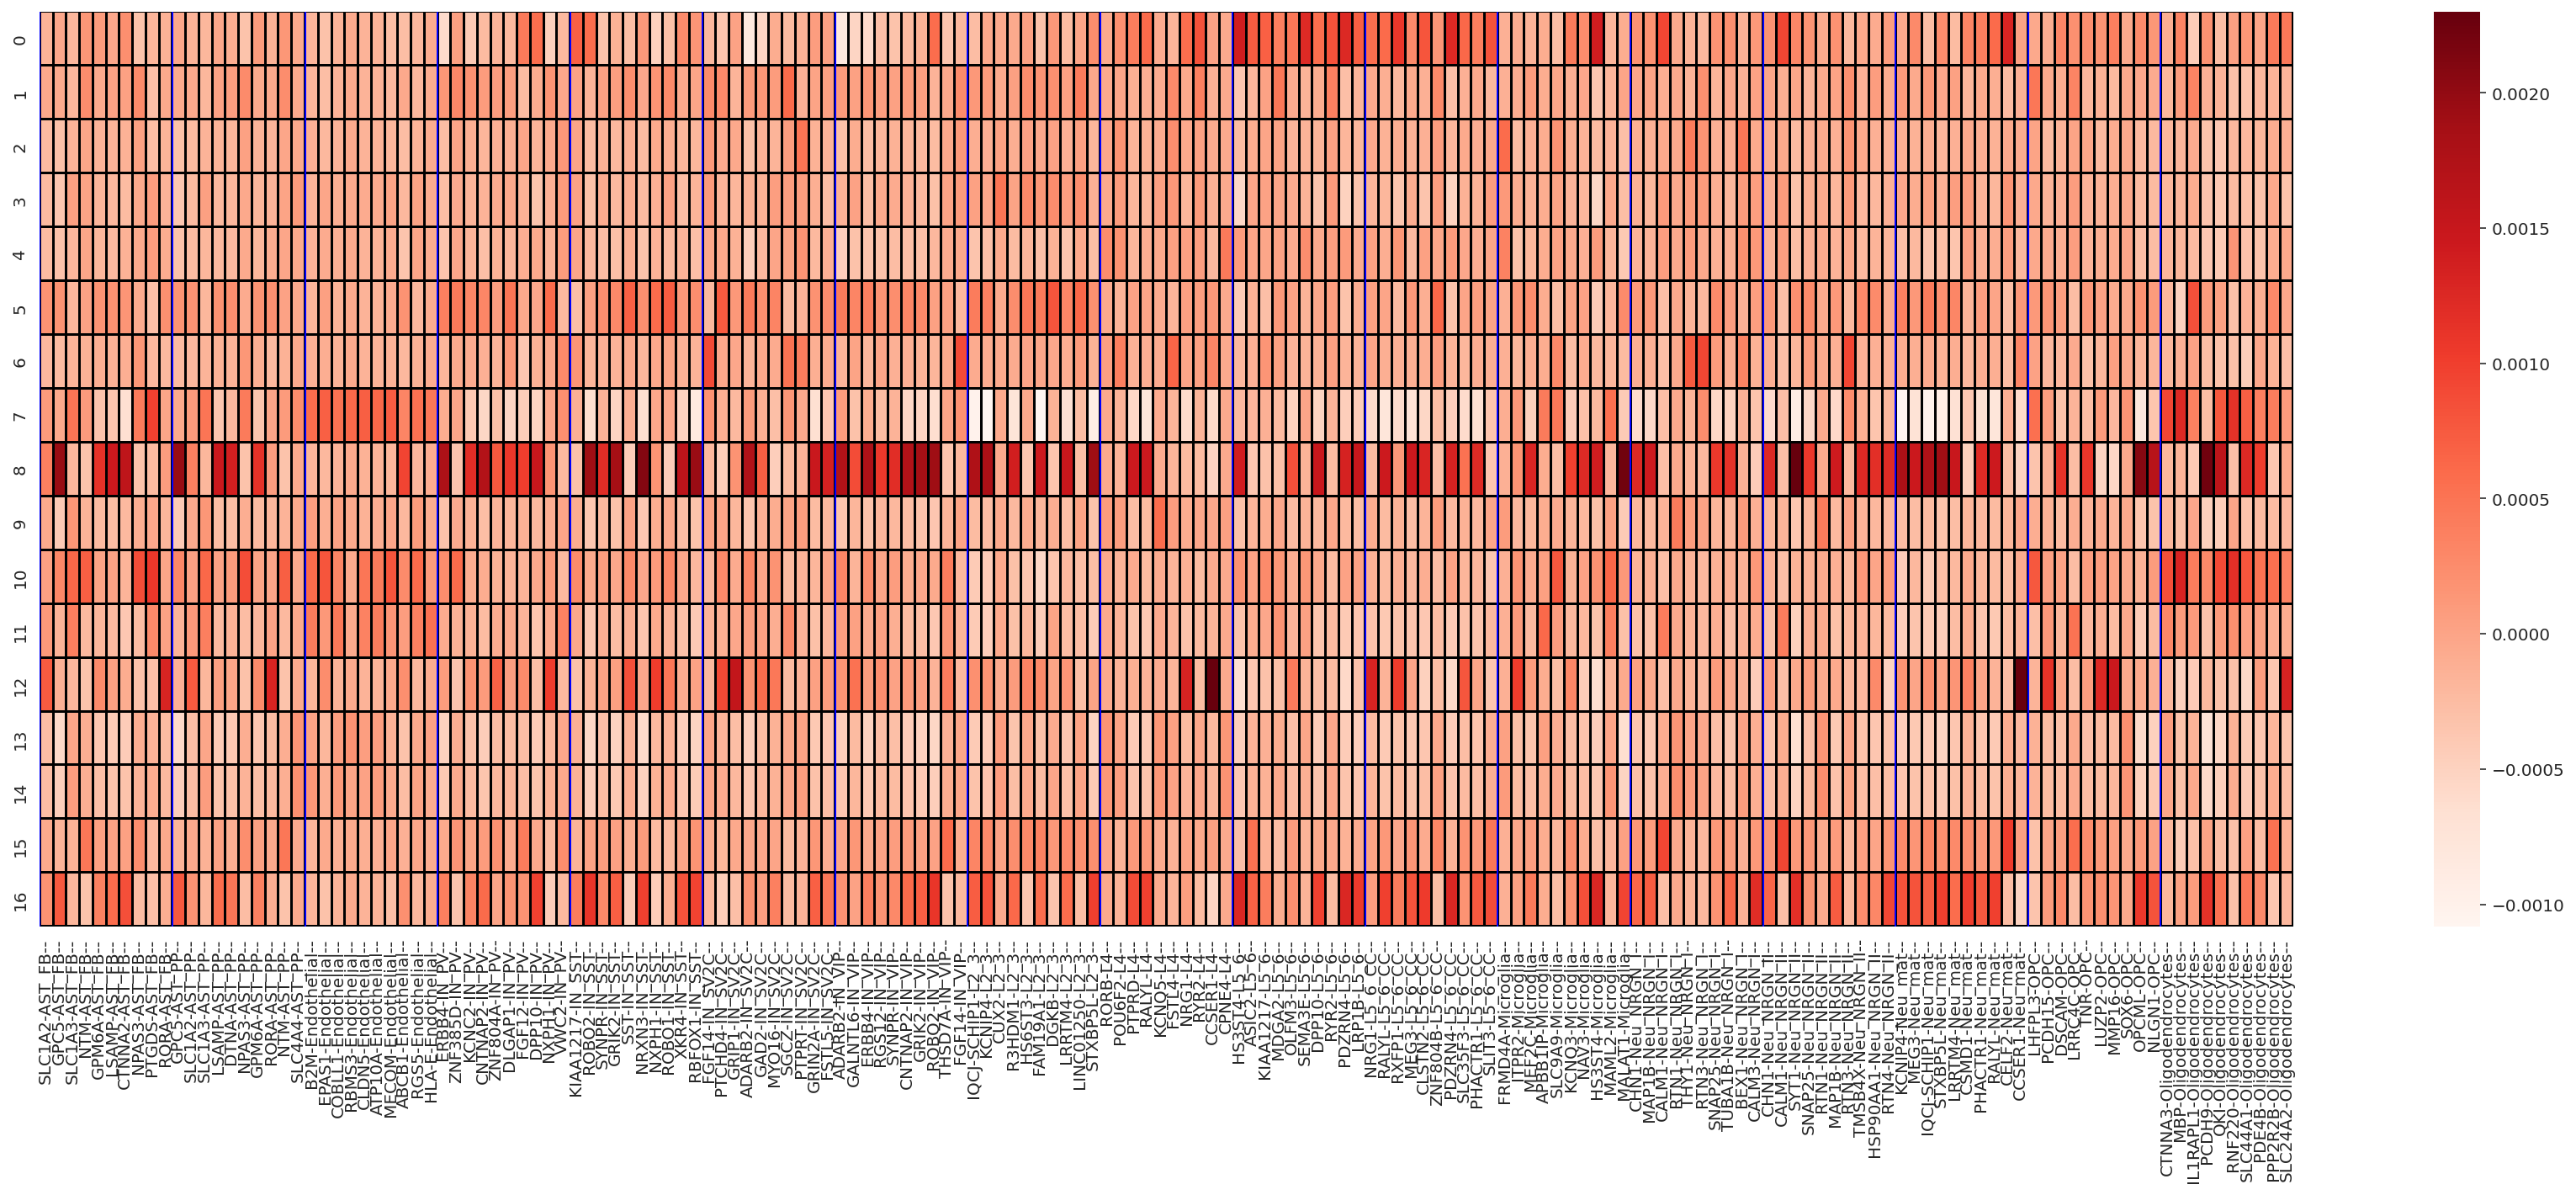

In [274]:
##Left: 1, 4, 5, 6, 7, 8, 2, 11, 12, 13, 14, 3
'''Left: 'AST_FB', 'AST_PP', 'Endothelial', 'IN_PV', 'IN_SST',
       'IN_VIP', 'L2_3', 'L4', 'L5_6_CC', 'Microglia','Neu_NRGN_I'
       'Neu_NRGN_II', 'Neu_mat', 'Oligodendrocytes '''
#row_id = 15
#z = M.loc[row_id:row_id,result_list]
#means = z.rolling(5, axis=1).mean()
##means = means.values[:, 4::5]
#sorted_indices = np.argsort(-means[0]) + 1
#new_order = []
##for i in sorted_indices:
#    for j in range(1,n+1):
#        new_order.append(n*i-j)
plt.figure(figsize=(30, 10))  # Adjust the figure size as needed
sns.heatmap(M[np.array(result_list)], annot=False, cmap='Reds', linewidth = 1, linecolor = 'black')
plt.xticks(ticks=np.arange(len(x_axis_labels)) + 0.5 , labels=np.array(x_axis_labels), rotation = 90)
for tick_loc in range(0, len(x_axis_labels), 10):
    plt.axvline(x=tick_loc, color='blue', linestyle='-', linewidth=1)
#plt.xticks(rotation=90)
plt.show()

In [192]:
mapping[row_id] = 'Neu_NRGN_I'

In [158]:
deg.columns

Index(['AST_FB', 'AST_PP', 'Endothelial', 'IN_PV', 'IN_SST', 'IN_SV2C',
       'IN_VIP', 'L2_3', 'L4', 'L5_6', 'L5_6_CC', 'Microglia', 'Neu_NRGN_I',
       'Neu_NRGN_II', 'Neu_mat', 'OPC', 'Oligodendrocytes'],
      dtype='object')